<a href="https://colab.research.google.com/github/natenorris10/MAT-422/blob/main/HW_1_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Linear Algebra HW 1.3

In [1]:
# Importing Libraries
import numpy as np
import matplotlib.pyplot as plt

###1.3.1 - QR Decomposition

QR Decomposition is essentially another way to structure the initial matrix $A$ by putting the resulting orthonormal basis vectors from the Gram-Schmidt process into a matrix $Q$, and creating an upper triangular matrix $R$ with the column vectors of $A$ and the projection vectors. It can then be verified that $A = QR$.  Additionally, the vectors in $A$ must be linearly independent.

In [12]:
A = np.array([[1, -1, 4],
              [1, 4, -2],
              [1, 4, 2],
              [1, -1, 0]])

In [13]:
def QR_decomp(A):
  Q = []
  R = []
  vectors = []
  proj = []

  for i in range(A.shape[1]):
    v = A.T[i] - sum(proj)
    vectors.append(v)

    if i+1 == A.shape[1]:
      break
    else:
      proj = []
      for j in range(len(vectors)):
        p = (np.inner(vectors[j], A.T[i+1])/np.inner(vectors[j], vectors[j]))*vectors[j]
        proj.append(p)

  for k in range(A.shape[1]):
    q = (1/np.sqrt(np.inner(vectors[k], vectors[k])))*vectors[k]
    Q.append(q)

  Q = np.array(Q).T
  R = Q.T @ A
  return Q, R

Q_matrix, R_matrix = QR_decomp(A)
print(Q_matrix)
print(R_matrix)
print(Q_matrix @ R_matrix)

[[ 0.5 -0.5  0.5]
 [ 0.5  0.5 -0.5]
 [ 0.5  0.5  0.5]
 [ 0.5 -0.5 -0.5]]
[[ 2.  3.  2.]
 [ 0.  5. -2.]
 [ 0.  0.  4.]]
[[ 1. -1.  4.]
 [ 1.  4. -2.]
 [ 1.  4.  2.]
 [ 1. -1.  0.]]


###1.3.2 - Least-Squares Problems

The least-squares problem is based around solving the typically inconsistent system $A\mathbf{x}=\mathbf{b}$.  A solution to this problem would be one such that $||\mathbf{b} - A\mathbf{\bar{x}}||\leq||\mathbf{b} - A\mathbf{x}||$, where $A$ is an $m \times n$ matrix, $\mathbf{b} \in \mathbb{R}^m$, and $\mathbf{\bar{x}} \in \mathbb{R}^n$ is a solution vector to the inequality, for all $\mathbf{x} \in \mathbb{R}^n$. We try to approximate $\mathbf{b}$ with $A\mathbf{x}$.  The problem we are trying to solve here is known as the least-squares problem:\
$\min\limits_{\mathbf{x} \in \mathbb{R}^m} || A\mathbf{x} - \mathbf{b}||$

One method for solving these problems are normal equations.  Normal equations are represented by the vector $\mathbf{\bar{x}}$ in the equation $A^TA\mathbf{\bar{x}}=A^T\mathbf{b}$.

In [15]:
# A few examples using Normal Equations

def normal_eq(A, b):

  ATA = A.T @ A
  ATb = A.T @ b

  ATA_inv = np.linalg.inv(ATA)

  x_bar = ATb @ ATA_inv
  return x_bar

matrix1 = np.array([[1, 5],
                    [2, -2],
                    [-1, 1]])
b1 = np.array([3, 2, 5])

matrix2 = np.array([[1, 1],
                    [1, 2],
                    [1, 3],
                    [1, 4]])
b2 = np.array([1, 2, 2, 3])

print(normal_eq(matrix1, b1))
print(normal_eq(matrix2, b2))

[0.33333333 0.53333333]
[0.5 0.6]


We can also find an approximation of a parabola.  For example, let's say we want to find a parabola that gives the best least-squares approximation for the points $(-1,1), (0,-1), (1,0),$ and $(2,2)$.  Using the equation of a parabola, we can set up a matrix A for each point that satisfies the equation $y = a + bx + cx^2$.  We solve this using the previous code and plot

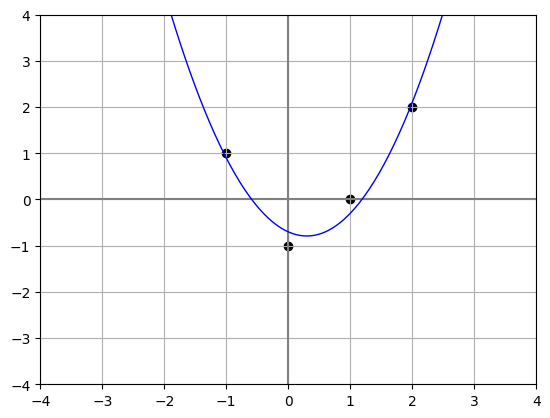

In [16]:
matrix3 = np.array([[1, -1, 1],
                    [1, 0, 0],
                    [1, 1, 1],
                    [1, 2, 4]])
b3 = np.array([1, -1, 0, 2])

x_bar3 = normal_eq(matrix3, b3)

x = np.linspace(-4, 4, 200)
y = np.linspace(-4, 4, 200)
eq = x_bar3[0] + x_bar3[1]*x + x_bar3[2]*x**2

x_vals = [-1, 0, 1, 2]
y_vals = [1, -1, 0, 2]

plt.plot(x, 0*y, color='gray')
plt.plot(x*0, y, color='gray')
plt.scatter(x_vals, y_vals, marker='o', color='black')
plt.plot(x, eq, color='blue', linewidth=1)

plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.grid()

plt.show()


QR decomposition is the most commonly used way to solve the least-squares problem.  By using the normal equations method, a small error in Gaussian elimination can cause a large error result in the least squares solution.  So, the QR method is used instead.  Let $A$ be an $n \times m$ matrix with linearly independent columns and $\mathbf{b} \in \mathbb{R}^m$.  Let $QR$ be the usual QR decomposition of $A$.  Then the solution vector, $\mathbf{\bar{x}}$, of the least-squares problem is given by $\mathbf{\bar{x}}=R^{-1}Q^T\mathbf{b}$.

In [29]:
# Using matrix3 above as well as QR Decomp function

Qmatrix3, Rmatrix3 = QR_decomp(matrix3)
print(np.allclose(Qmatrix3 @ Rmatrix3, matrix3)) # Just to check

new_xbar3 = np.linalg.inv(Rmatrix3) @ Qmatrix3.T @ b3

print(new_xbar3)
print(x_bar3)

True
[-0.7 -0.6  1. ]
[-0.7 -0.6  1. ]


Both the QR decomposition and the normal equations provide the same result

###1.3.3 - Linear Regression

When we have data $\{\mathbf{x}_i, y_i\}_{i=1}^n$ with each $\mathbf{x} = (x_{i1}, x_{i2}, ..., x_{id})^T$, we try to find a function that fits this data. The most common approach is to find the coefficients, $\beta_j$, such that $\sum_{i=1}^n{(y_i - \hat{y_i})^2}$ is minimized, where $\hat{y_i}$ is defined as $\hat{y_i}=\beta_0 + \sum_{j=1}^{d}{\beta_j x_{ij}}.$

This can be rewritten in the form of matrices like so,\
$\hat{y}=\begin{pmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{pmatrix},
A = \begin{pmatrix} 1 & \mathbf{x}_1^T \\ 1 & \mathbf{x}_2^T \\ \vdots & \vdots \\ 1 & \mathbf{x}_n^T \end{pmatrix}, \hspace{.01cm} and \hspace{.2cm}
\boldsymbol{{\beta}} = \begin{pmatrix} \beta_1 \\ \beta_2 \\ \vdots \\ \beta_n \end{pmatrix}$


Now, the problem has just become $\min\limits_{\beta}||\mathbf{y} - A\boldsymbol{\beta}||^2,$ and this is exactly the same as the least squares problem.  So, the methods previously shown will work for linear regression.